In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [2]:
df = pd.read_csv("knn_loan_classification_2200.csv")

In [3]:
df.head()

,Applicant_ID,Age,Monthly_Income_TL,Employment_Type,Employment_Tenure_Years,Education_Level,Marital_Status,Dependents,City,Home_Ownership,Credit_Score,Existing_Monthly_Debt_TL,Requested_Loan_Amount_TL,Loan_Term_Months,Loan_Purpose,Late_Payments_Last_2Y,Has_Guarantor,Loan_Approved
0,LA-00001,66,79643.03,Public_Sector,21.0,Bachelor,Single,3.0,Bursa,Owner,548.0,23048.25,263505.91,48,Debt_Consolidation,0.0,No,No
1,LA-00002,27,57432.73,Private_Sector,2.0,Bachelor,Divorced,0.0,Izmir,Mortgage,760.0,19122.91,610091.54,60,Vehicle,0.0,No,Yes
2,LA-00003,22,65897.61,Freelancer,4.0,Bachelor,Married,1.0,Bursa,Rent,601.0,26877.13,258797.45,36,Home,3.0,No,No
3,LA-00004,66,43989.89,Freelancer,27.0,Bachelor,Single,3.0,Antalya,Mortgage,585.0,23128.23,255098.11,12,Business,2.0,No,Yes
4,LA-00005,68,60924.81,Freelancer,31.0,Master,Married,1.0,Konya,Mortgage,758.0,16737.50,361874.58,120,Vehicle,0.0,No,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Applicant_ID              2200 non-null   object 
 1   Age                       2200 non-null   int64  
 2   Monthly_Income_TL         2141 non-null   float64
 3   Employment_Type           2164 non-null   object 
 4   Employment_Tenure_Years   2144 non-null   float64
 5   Education_Level           2200 non-null   object 
 6   Marital_Status            2200 non-null   object 
 7   Dependents                2159 non-null   float64
 8   City                      2200 non-null   object 
 9   Home_Ownership            2200 non-null   object 
 10  Credit_Score              2125 non-null   float64
 11  Existing_Monthly_Debt_TL  2126 non-null   float64
 12  Requested_Loan_Amount_TL  2200 non-null   float64
 13  Loan_Term_Months          2200 non-null   int64  
 14  Loan_Pur

In [5]:
df.isnull().sum()

Applicant_ID                 0
Age                          0
Monthly_Income_TL           59
Employment_Type             36
Employment_Tenure_Years     56
Education_Level              0
Marital_Status               0
Dependents                  41
City                         0
Home_Ownership               0
Credit_Score                75
Existing_Monthly_Debt_TL    74
Requested_Loan_Amount_TL     0
Loan_Term_Months             0
Loan_Purpose                 0
Late_Payments_Last_2Y       44
Has_Guarantor                0
Loan_Approved                0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2200.0,44.934091,13.969294,21.00,33.0000,44.00,57.0000,69.00
Monthly_Income_TL,2141.0,58821.821649,36457.512271,15000.00,38815.6000,51551.16,69768.7800,610915.05
Employment_Tenure_Years,2144.0,10.777052,7.000014,0.00,5.0000,11.00,16.0000,31.00
Dependents,2159.0,1.512274,1.250658,0.00,1.0000,1.00,2.0000,5.00
Credit_Score,2125.0,664.875765,82.398740,398.00,609.0000,663.00,719.0000,900.00
Existing_Monthly_Debt_TL,2126.0,20420.849925,19225.163739,1065.91,9226.2225,16744.15,26048.6675,340855.62
Requested_Loan_Amount_TL,2200.0,345029.414009,382148.908980,19075.64,155518.2850,256531.65,417608.8400,9179726.09
Loan_Term_Months,2200.0,53.820000,33.873052,12.00,24.0000,48.00,84.0000,120.00
Late_Payments_Last_2Y,2156.0,0.697124,1.166274,0.00,0.0000,0.00,1.0000,8.00


In [7]:
#data cleaning

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Applicant_ID              2200 non-null   object 
 1   Age                       2200 non-null   int64  
 2   Monthly_Income_TL         2141 non-null   float64
 3   Employment_Type           2164 non-null   object 
 4   Employment_Tenure_Years   2144 non-null   float64
 5   Education_Level           2200 non-null   object 
 6   Marital_Status            2200 non-null   object 
 7   Dependents                2159 non-null   float64
 8   City                      2200 non-null   object 
 9   Home_Ownership            2200 non-null   object 
 10  Credit_Score              2125 non-null   float64
 11  Existing_Monthly_Debt_TL  2126 non-null   float64
 12  Requested_Loan_Amount_TL  2200 non-null   float64
 13  Loan_Term_Months          2200 non-null   int64  
 14  Loan_Pur

In [9]:
df.drop("Applicant_ID",axis=1,inplace=True)
df.drop("Employment_Tenure_Years",axis=1,inplace=True)

In [10]:
X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [11]:
numeric_columns= X.select_dtypes(include="number").columns
categoric_columns= X.select_dtypes(exclude="number").columns

In [12]:
numeric_columns,categoric_columns

(Index(['Age', 'Monthly_Income_TL', 'Dependents', 'Credit_Score',
        'Existing_Monthly_Debt_TL', 'Requested_Loan_Amount_TL',
        'Loan_Term_Months', 'Late_Payments_Last_2Y'],
       dtype='object'),
 Index(['Employment_Type', 'Education_Level', 'Marital_Status', 'City',
        'Home_Ownership', 'Loan_Purpose', 'Has_Guarantor'],
       dtype='object'))

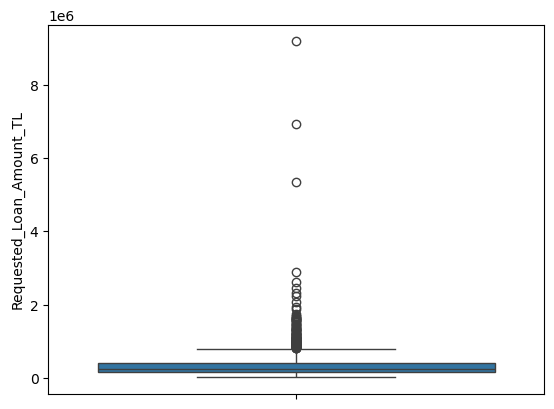

In [13]:
sns.boxplot(data=df,y=df["Requested_Loan_Amount_TL"])
plt.show()

In [14]:
df = df[df["Requested_Loan_Amount_TL"]<800000]

In [15]:
df.shape

(2073, 16)

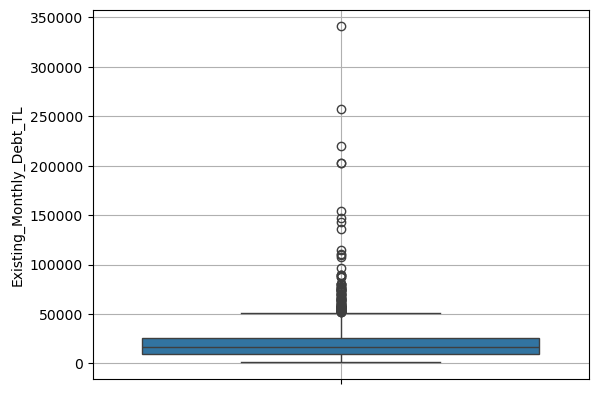

In [16]:
sns.boxplot(data=df,y=df["Existing_Monthly_Debt_TL"])
plt.grid()
plt.show()

In [17]:
df = df[df["Existing_Monthly_Debt_TL"]<50000]

In [18]:
df.shape

(1904, 16)

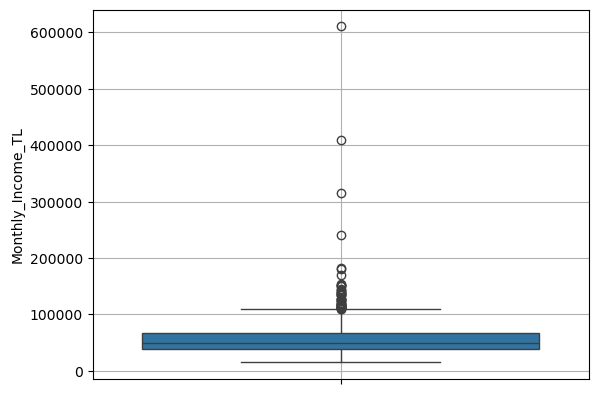

In [19]:
sns.boxplot(data=df,y=df["Monthly_Income_TL"])
plt.grid()
plt.show()

In [20]:
df= df[df["Monthly_Income_TL"]<110000]

In [21]:
df.shape

(1803, 16)

In [44]:
from sklearn.preprocessing import RobustScaler,LabelEncoder,OneHotEncoder

In [23]:
len(categoric_columns)

7

In [25]:
label  = LabelEncoder()
for i in range(0,7):
    df[categoric_columns[i]] = label.fit_transform(df[categoric_columns[i]])

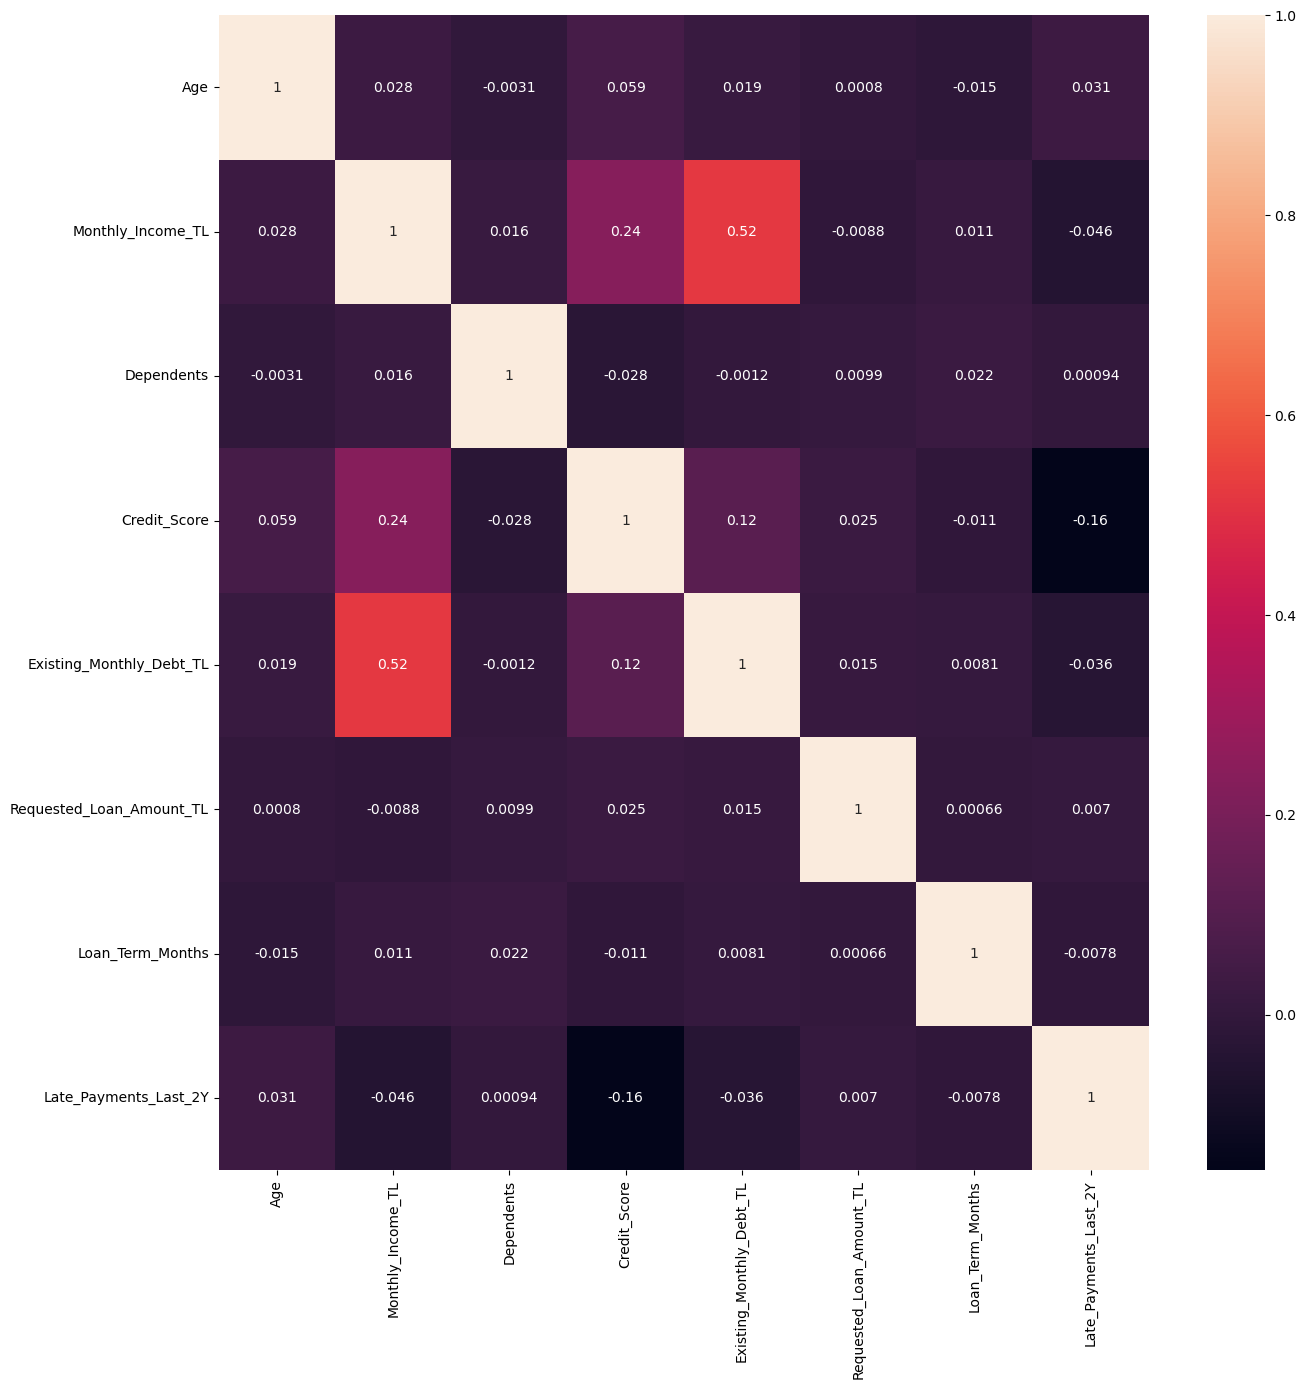

In [28]:
correlation = df[numeric_columns].corr()
plt.figure(figsize=(15,15))
sns.heatmap(correlation,annot=True)
plt.show()

In [29]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [45]:
numeric_pipeline = Pipeline([
    ("scaler",RobustScaler()),
    ("impute",SimpleImputer(strategy="median"))
])
categoric_pipeline = Pipeline([
    ("label",OneHotEncoder(handle_unknown="ignore")),
    ("impute",SimpleImputer(strategy="most_frequent"))
])

In [46]:
preprocessor = ColumnTransformer([
    ("numeric",numeric_pipeline,numeric_columns),
    ("categoric",categoric_pipeline,categoric_columns)
])

In [47]:
pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",KNeighborsClassifier())
])

In [48]:
param_grid = {
    "model__n_neighbors": [5, 7, 9, 11, 15, 21, 31],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2] 
}

In [49]:
grid = GridSearchCV(pipeline,param_grid,cv=5,scoring="accuracy")

In [50]:
grid.fit(X_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__n_neighbors': [5, 7, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categoric', ...)]"


In [51]:
print(grid.best_params_)

{'model__n_neighbors': 31, 'model__p': 2, 'model__weights': 'distance'}


In [52]:
y_pred = grid.predict(X_test)

In [53]:
score = accuracy_score(y_pred,y_test)
print("Score : ",score)
print(classification_report(y_pred,y_test))
print("Confusion Matrix : \n ", confusion_matrix(y_pred,y_test))

Score :  0.6963636363636364
              precision    recall  f1-score   support

          No       0.71      0.72      0.72       292
         Yes       0.68      0.67      0.67       258

    accuracy                           0.70       550
   macro avg       0.70      0.69      0.69       550
weighted avg       0.70      0.70      0.70       550

Confusion Matrix : 
  [[210  82]
 [ 85 173]]
